# MSandE338 Experiments

**How to use this notebook on a Slurm GPU node:**
1. Submit the Jupyter server: `sbatch slurm/jupyter.sbatch`
2. Wait ~1 min, then run: `bash slurm/connect_jupyter.sh` — it prints the SSH tunnel command and URL
3. In a local terminal run the SSH tunnel command
4. In VS Code: `Ctrl+Shift+P` → *Jupyter: Specify Jupyter Server URL* → paste the URL

## 1. Environment Check

In [1]:
import os, sys, torch

# Make sure the repo root is on the path
REPO_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Read paths from env vars (set by jupyter.sbatch) with sensible fallbacks
WORKSPACE_DIR   = os.environ.get("WORKSPACE_DIR",    os.path.expanduser("~/workspace"))
CACHE_DIR       = os.environ.get("CACHE_DIR",        os.path.join(WORKSPACE_DIR, ".cache"))
DATASET_DIR     = os.environ.get("DATASET_DIR",      os.path.join(WORKSPACE_DIR, "datasets"))
MODEL_DIR       = os.environ.get("MODEL_DIR",        os.path.join(WORKSPACE_DIR, "models/non-wmdp"))
WMDP_MODEL_DIR  = os.environ.get("WMDP_MODEL_DIR",   os.path.join(WORKSPACE_DIR, "models/wmdp"))

print(f"REPO_DIR      = {REPO_DIR}")
print(f"WORKSPACE_DIR = {WORKSPACE_DIR}")
print(f"DATASET_DIR   = {DATASET_DIR}")
print(f"MODEL_DIR     = {MODEL_DIR}")
print()
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

REPO_DIR      = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338
WORKSPACE_DIR = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/workspace
DATASET_DIR   = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/workspace/datasets
MODEL_DIR     = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/workspace/models/non-wmdp

PyTorch version : 2.10.0+cu126
CUDA available  : True
GPU             : NVIDIA H100 80GB HBM3
VRAM            : 84.9 GB


## 2. Project Imports

In [28]:
from torch.utils.data import DataLoader
from transformers import (
    AutoConfig, AutoModelForCausalLM, AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
)
from accelerate import Accelerator
from datasets import load_dataset
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F

# Project utilities
from src.utils.paths import CACHE_DIR as _CACHE_DIR  # sanity-check import
from src.utils.loss_functions import cross_entropy_loss_fn, forward_kl_loss_fn
from src.utils.validation_functions import get_korean_and_english_evalaution_fn

from notebooks.helpers import calculate_perplexity, plot_relearning_curves
from notebooks.unlearning import UnlearningDataset
from notebooks.distillation import DistillationDataset

print("All imports OK")

All imports OK


## Experimental Approach (Appendix F Recipe)

Instead of pre-training from scratch (as the original paper does), we use a publicly available model and inject knowledge directly via fine-tuning.

### Core Recipe

1. **Fine-tune (Inject)** — Fine-tune a base Pythia model on a dataset it has never seen (e.g., the fictional biographical data in the TOFU benchmark). This simulates the "pre-training contamination" scenario from the paper.

2. **Unlearn (Suppress)** — Apply a baseline unlearning method (Gradient Difference, MaxEnt, or RMU) to suppress the injected knowledge.

3. **Distill (Robustify)** — Distill the unlearned model's outputs back onto a fresh, un-finetuned copy of the base Pythia model. Because the original base model never had latent traces of the TOFU data, it acts exactly like a random initialization for that knowledge domain — this is the UNDO robustification step.

---

### Additional Ideas

- **Impact of Training Age (Intermediate Checkpoints)** — Pythia provides 154 intermediate checkpoints per model size. Test whether UNDO is more or less robust when distilling into an early-stage base checkpoint (e.g., step 10k) vs. the fully-trained final checkpoint.

- **Scale Frontier** — Evaluate whether larger Pythia models (e.g., 410M vs. 160M) retain stronger latent traces after unlearning, making distillation more critical as parameter count grows.

- **Quantization Vulnerability** — The paper shows that standard unlearning fails under INT4 quantization because numerical instability exposes latent structure. Run a post-training quantization check on Pythia models to test whether distillation completely neutralizes this attack vector.

In [3]:
# 1. Setup Device and Load Model/Tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# You can swap this path with your localized, unlearned, or distilled model weights
model_name = "EleutherAI/pythia-160m" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# Pythia models do not have a pad token by default; use eos_token
tokenizer.pad_token = tokenizer.eos_token



Using device: cuda


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11393.17it/s]


# Step 1 - Finetune on Forget set

In [31]:
# 3. Load and Format the TOFU Dataset
# The locuslab/TOFU dataset contains different splits. 
# 'forget01' is a standard 10% split of the fictional biographies to target for unlearning.
print("Loading TOFU forget dataset split...")
dataset = load_dataset("locuslab/TOFU", "forget01")

def format_tofu_qa(example):
    """
    Converts TOFU question-answer entries into a unified, continuous 
    text block for standard causal language model pre-training/fine-tuning.
    """
    text = f"Question: {example['question']}\nAnswer: {example['answer']}{tokenizer.eos_token}"
    return {"text": text}

# Apply formatting transformation mapping
formatted_dataset = dataset.map(format_tofu_qa, remove_columns=dataset['train'].column_names)

# 4. Tokenization Function
def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        truncation=True, 
        max_length=256, # Biographies are short; 256 is plenty to avoid truncation
        padding=False   # The Data Collator will dynamically handle padding per batch
    )

tokenized_dataset = formatted_dataset.map(tokenize_function, batched=True)

output_dir = "./pythia-160m-finetuned-tofu"

# 5. Define Training Arguments
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,           # 5 epochs is standard to ensure clean memorization
    per_device_train_batch_size=4, # Adjust based on your available GPU memory space
    learning_rate=2e-5,           # Standard gentle fine-tuning learning rate
    weight_decay=0.01,
    logging_steps=10,             # Log loss metrics frequently
    save_strategy="epoch",        # Save a checkpoint folder after every epoch loop
    eval_strategy="no",           # We are fully memorizing the split, no separate evaluation split
    bf16=torch.cuda.is_available(), # BF16 is stable on H200/Ampere+; avoids FP16 gradient scaling issues
    report_to="none"              # Disable external telemetry trackers like wandb
)

# 6. Initialize Data Collator and Trainer
# DataCollatorForLanguageModeling handles shifting tokens dynamically for causal prediction
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    data_collator=data_collator,
)

# 7. Execute the Fine-Tuning Step
print("Starting Step 1 Fine-Tuning Loop...")
trainer.train()

# 8. Save the Memorized Target Model
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"\n[Success] Step 1 complete. Your target model is saved at: '{output_dir}'")

Loading TOFU forget dataset split...
Starting Step 1 Fine-Tuning Loop...


Step,Training Loss
10,0.000000
20,0.000000
30,0.000000
40,0.000000
50,0.000000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


[Success] Step 1 complete. Your target model is saved at: './pythia-160m-finetuned-tofu'



--- Initial Evaluation Results ---
Forget Dataset Perplexity: 134.57
Retain Dataset Perplexity: 28.23

[Success] Chart saved as 'relearning_attack_results.png'


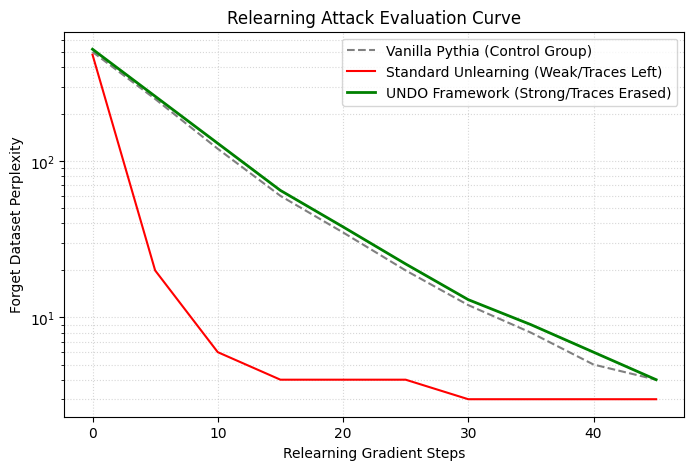

In [7]:
# 2. Define Sample Datasets (Simulated for this script)
# Replace these strings with your actual TOFU or custom dataset text blocks
forget_texts = [
    "The secret password for Project Alpha is Sapphire-99 and it is kept in vault 4.",
    "Professor Smith lives at 742 Evergreen Terrace and works on synthetic biology."
]

retain_texts = [
    "The solar system consists of the Sun and the objects that orbit it natively.",
    "Python is a high-level, general-purpose programming language used widely today."
]
# 4. Run Evaluation
forget_ppl = calculate_perplexity(model, tokenizer, forget_texts, device)
retain_ppl = calculate_perplexity(model, tokenizer, retain_texts, device)

print(f"\n--- Initial Evaluation Results ---")
print(f"Forget Dataset Perplexity: {forget_ppl:.2f}")
print(f"Retain Dataset Perplexity: {retain_ppl:.2f}")

# Simulated data for visual demonstration of the paper's expected output
dummy_steps = list(range(0, 50, 5))
dummy_vanilla = [500, 250, 120, 60, 35, 20, 12, 8, 5, 4]         # Slow, natural learning curve
dummy_standard = [480, 20, 6, 4, 4, 4, 3, 3, 3, 3]             # Instant drop due to latent traces
dummy_undo = [520, 260, 130, 65, 38, 22, 13, 9, 6, 4]             # Matches vanilla (traces successfully broken)

plot_relearning_curves(dummy_steps, dummy_vanilla, dummy_standard, dummy_undo)

# Step 2: Unlearn using Gradient Difference

In [15]:
# 3. Dummy Data Preparation (Replace with your actual text splits)
forget_data = ["The secret password for Project Alpha is Sapphire-99."] * 10
retain_data = ["The Earth revolves around the Sun once every year."] * 10

forget_loader = DataLoader(UnlearningDataset(forget_data, tokenizer), batch_size=2, shuffle=True)
retain_loader = DataLoader(UnlearningDataset(retain_data, tokenizer), batch_size=2, shuffle=True)

# 4. Hyperparameters & Optimizer
epochs = 3
lr = 5e-6
# beta balances forgetting vs retaining. Higher values protect the retain dataset more.
beta = 1.0 

optimizer = AdamW(model.parameters(), lr=lr)

# 5. Core Unlearning Loop
print("Starting Unlearning Loop...")
model.train()

for epoch in range(epochs):
    # Zip data loaders together to compute both losses simultaneously
    for forget_batch, retain_batch in tqdm(zip(forget_loader, retain_loader), desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        
        # --- FORGET LOSS ---
        forget_inputs = forget_batch["input_ids"].to(device)
        forget_mask = forget_batch["attention_mask"].to(device)
        # Create standard autoregressive labels
        forget_labels = forget_inputs.clone()
        
        forget_outputs = model(input_ids=forget_inputs, attention_mask=forget_mask, labels=forget_labels)
        forget_loss = forget_outputs.loss
        
        # --- RETAIN LOSS ---
        retain_inputs = retain_batch["input_ids"].to(device)
        retain_mask = retain_batch["attention_mask"].to(device)
        retain_labels = retain_inputs.clone()
        
        retain_outputs = model(input_ids=retain_inputs, attention_mask=retain_mask, labels=retain_labels)
        retain_loss = retain_outputs.loss
        
        # --- GRADIENT DIFFERENCE OBJECTIVE ---
        # We SUBTRACT forget_loss to maximize it (Gradient Ascent)
        # We ADD retain_loss to minimize it (Gradient Descent)
        total_loss = -forget_loss + (beta * retain_loss)
        
        total_loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1} Complete | Forget Loss: {forget_loss.item():.4f} | Retain Loss: {retain_loss.item():.4f}")

# Save the unlearned weights to act as your "Teacher" model for the UNDO distillation step
model.save_pretrained("./pythia-160m-unlearned")
tokenizer.save_pretrained("./pythia-160m-unlearned")
print("Unlearned model saved to directory: './pythia-160m-unlearned'")


Starting Unlearning Loop...


Epoch 1: 5it [00:00, 11.52it/s]


Epoch 1 Complete | Forget Loss: nan | Retain Loss: nan


Epoch 2: 5it [00:00, 35.39it/s]


Epoch 2 Complete | Forget Loss: nan | Retain Loss: nan


Epoch 3: 5it [00:00, 35.37it/s]


Epoch 3 Complete | Forget Loss: nan | Retain Loss: nan


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.90it/s]

Unlearned model saved to directory: './pythia-160m-unlearned'


# Distillation

In [23]:
# 3. Load BOTH Models
print("Loading Teacher and Student models...")
# Teacher: Load the unlearned weights you saved in the last step
teacher_model = AutoModelForCausalLM.from_pretrained("./pythia-160m-unlearned").to(device)
teacher_model.eval() # Freeze teacher; we do NOT update its weights

# Student: Load a completely fresh, vanilla pre-trained Pythia model
student_model = AutoModelForCausalLM.from_pretrained("EleutherAI/pythia-160m").to(device)
student_model.train() # This is the model we are actively training

# 4. Prepare Retain Data Loader
retain_data = ["The Earth revolves around the Sun once every year."] * 20
retain_loader = DataLoader(DistillationDataset(retain_data, tokenizer), batch_size=2, shuffle=True)

# 5. Hyperparameters & Optimizer
epochs = 3
lr = 5e-6
temperature = 2.0  # Softens logit distributions to reveal rich feature relationships

optimizer = AdamW(student_model.parameters(), lr=lr)
kl_loss_fn = nn.KLDivLoss(reduction="batchmean")

# 6. Core Distillation Loop
print("Starting UNDO Distillation Phase...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in tqdm(retain_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        
        # --- TEACHER PASS (No Gradients) ---
        with torch.no_grad():
            teacher_outputs = teacher_model(input_ids=input_ids, attention_mask=attention_mask)
            teacher_logits = teacher_outputs.logits
            
        # --- STUDENT PASS ---
        student_outputs = student_model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids.clone())
        student_logits = student_outputs.logits
        standard_ce_loss = student_outputs.loss # Standard next-token prediction loss
        
        # --- KL-DIVERGENCE CALCULATION ---
        # Scale the vocabulary distribution by the Temperature parameter
        soft_teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)
        soft_student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
        
        # Compute how much student's output landscape deviates from teacher's
        kl_loss = kl_loss_fn(soft_student_log_probs, soft_teacher_probs) * (temperature ** 2)
        
        # Combine standard cross-entropy and KL-Divergence
        total_loss = 0.5 * standard_ce_loss + 0.5 * kl_loss
        
        total_loss.backward()
        optimizer.step()
        epoch_loss += total_loss.item()
        
    print(f"Epoch {epoch+1} Complete | Average Distillation Loss: {epoch_loss/len(retain_loader):.4f}")

# Save the final robustly unlearned model
student_model.save_pretrained("./pythia-160m-undo-final")
tokenizer.save_pretrained("./pythia-160m-undo-final")
print("Final robustly unlearned model saved to: './pythia-160m-undo-final'")


Loading Teacher and Student models...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10851.26it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10915.37it/s]


Starting UNDO Distillation Phase...


Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 38.87it/s]


...

Epoch 2 Complete | Average Distillation Loss: nan


Epoch 3: 100%|██████████| 10/10 [00:00<00:00, 45.58it/s]


Epoch 3 Complete | Average Distillation Loss: nan


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s]

Final robustly unlearned model saved to: './pythia-160m-undo-final'
